In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
df_train = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
df_test  = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

df_train.head()

Train shape: (175341, 45)
Test shape : (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [3]:
drop_cols = ['id', 'attack_cat']

df_train = df_train.drop(columns=drop_cols)
df_test  = df_test.drop(columns=drop_cols)

In [4]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test  = df_test.drop(columns=['label'])
y_test  = df_test['label']

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=50
        ), cat_features)
    ]
)

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=18,
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

In [7]:
from sklearn.pipeline import Pipeline

pipeline_dt = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', dt_model)
])

In [8]:
start_time = time.time()
pipeline_dt.fit(X_train, y_train)
training_time = time.time() - start_time

print("Training Time (s):", round(training_time, 2))

Training Time (s): 5.41


In [ ]:
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]

THRESHOLD = 0.4   
y_pred_dt = (y_prob_dt > THRESHOLD).astype(int)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.8896419375212554
Precision: 0.8491234829512618
Recall   : 0.9723374216888732
F1 Score : 0.9065630077538512
ROC-AUC  : 0.9458649119648194


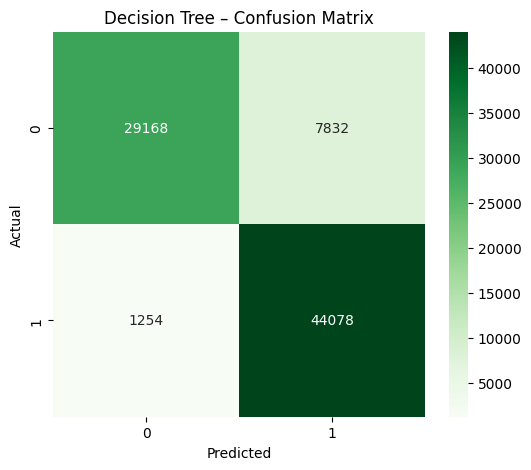

In [12]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree – Confusion Matrix")
plt.show()

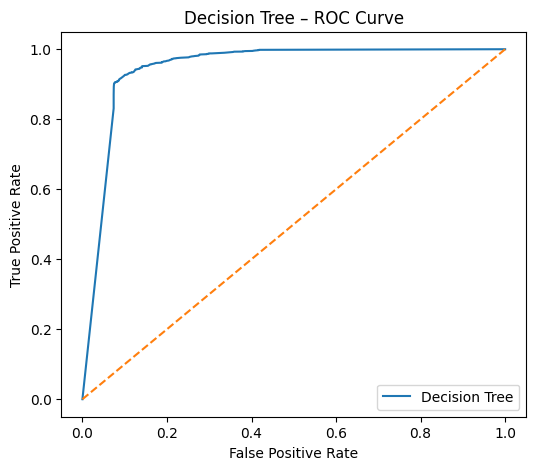

In [13]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree – ROC Curve")
plt.legend()
plt.show()

In [14]:
import joblib

joblib.dump(pipeline_dt, "decision_tree_ids_model.joblib")
print("Decision Tree model saved")

Decision Tree model saved
